In [22]:
import pandas as pd
import re
from sqlalchemy import create_engine
import os
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
db_path = os.path.join(project_root, "data", "weather.db")
connection_str = f"sqlite:///{db_path}"
engine = create_engine(connection_str, connect_args={"check_same_thread": False})

In [23]:
def single_station_load(engine, station_id):
    query = "SELECT * FROM clean_station_data WHERE station_id=:sid"
    params = {'sid': station_id}
    df_out = pd.read_sql(query, engine, params=params)
    return df_out

df_haifa = single_station_load(engine, 43)
df_tel_aviv = single_station_load(engine, 178)
df_afula = single_station_load(engine, 16)
df_afula.head()

,timestamp,rain,wsmax,wdmax,ws,stdwd,td,rh,tdmax,tdmin,ws1mm,ws10mm,u_vec,v_vec,rain_intensity_max,station_id,latitude,longitude
0,2019-12-31 22:00:00.000000,0.0,1.4,322.0,0.666667,13.300000,8.833333,91.333333,9.5,8.1,1.3,1.2,0.312851,-0.347125,0.0,16,32.596,35.2769
1,2019-12-31 23:00:00.000000,0.0,1.5,276.0,0.866667,11.416667,7.783333,97.166667,8.2,7.1,1.3,1.2,0.852835,0.133639,0.0,16,32.596,35.2769
2,2020-01-01 00:00:00.000000,0.0,1.8,290.0,1.033333,13.050000,6.883333,99.833333,7.3,6.2,1.7,1.3,0.992793,0.091221,0.0,16,32.596,35.2769
3,2020-01-01 01:00:00.000000,0.0,1.8,352.0,0.616667,24.750000,6.000000,100.000000,6.5,5.5,1.6,1.2,0.318678,0.120158,0.0,16,32.596,35.2769
4,2020-01-01 02:00:00.000000,0.0,1.8,229.0,0.916667,14.600000,5.783333,100.000000,6.2,5.5,1.6,1.4,0.383916,0.733935,0.0,16,32.596,35.2769


In [24]:
print(df_afula.shape)
print(df_afula.columns.tolist())

(43848, 18)
['timestamp', 'rain', 'wsmax', 'wdmax', 'ws', 'stdwd', 'td', 'rh', 'tdmax', 'tdmin', 'ws1mm', 'ws10mm', 'u_vec', 'v_vec', 'rain_intensity_max', 'station_id', 'latitude', 'longitude']


In [25]:
def sort_by_ts(df: pd.DataFrame):
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df.set_index('timestamp', inplace=True)
    df.sort_index(axis=0, ascending=True, inplace=True)

sort_by_ts(df_afula)
sort_by_ts(df_tel_aviv)
sort_by_ts(df_haifa)

## Feature engineering functions (timelags/upstream)

In [26]:
def create_local_lags(df: pd.DataFrame, lag_hours=[1, 2, 3, 6, 12, 24], target_lag: int = 1):
    """
    Creates autoregressive lag features for a single station's dataframe.
    Assumes df is already filtered for ONE station and sorted by time.
    """
    df_out = df.copy()
    target_cols = ['rain', 'u_vec', 'v_vec', 'td', 'rh', 'rain_intensity_max']

    for col in target_cols:
        if col in df_out.columns:
            for h in lag_hours:
                feat_name = f"{col}_t-{h}h"
                df_out[feat_name] = df_out[col].shift(h)


    df_out[f'target_rain_t+{target_lag}'] = df_out['rain'].shift(-target_lag)
    return df_out

In [27]:
def add_upstream_features(df_target: pd.DataFrame, df_upstream: pd.DataFrame, upstream_name, lag_hours=[1, 2, 3], join_type='left'):
    """
    Joins upstream station data onto the target station.
    """
    force_cols = ['rain', 'u_vec', 'v_vec', 'rh']
    renamed_cols = {c: f"{c}_{upstream_name}" for c in force_cols}
    df_force = df_upstream[force_cols].rename(columns=renamed_cols).reindex(df_target.index)
    
    # Add physics features
    df_force[f"u_convergence_{upstream_name}"] = df_force[f"u_vec_{upstream_name}"] - df_target["u_vec"]
    df_force[f"v_convergence_{upstream_name}"] = df_force[f"v_vec_{upstream_name}"] - df_target["v_vec"]
    df_force[f"moisture_flux_{upstream_name}"] = df_force[f"u_vec_{upstream_name}"] * df_force[f"rh_{upstream_name}"]

    cols_to_lag = list(df_force.columns)
    for col in cols_to_lag:
        for h in lag_hours:
            df_force[f"{col}_t-{h}h"] = df_force[col].shift(h)

    # Constraint flitering logic
    rain_keywords = ['rain', 'convergence', 'moisture_flux', 'rh']
    full_constraints = {}
    for col in df_force.columns:
        if any(keyword in col for keyword in rain_keywords):
            full_constraints[col] = 1

    df_merged = df_target.join(df_force, how=join_type)

    return df_merged

In [28]:
def get_constraints(df: pd.DataFrame, target_pattern: str = r't\+\d+'):
    rain_keywords = ['rain', 'convergence', 'moisture_flux', 'rh']
    negative_keywords = ['td', 'tdmax']
    full_constraints = {}
    for col in df.columns:
        if re.search(target_pattern, col):
            continue

        if any(keyword in col for keyword in negative_keywords):
            full_constraints[col] = -1

        if any(keyword in col for keyword in rain_keywords):
            full_constraints[col] = 1

    return full_constraints

## Data splitting with time-series preservation

In [29]:
def temporal_split(df: pd.DataFrame, target_col, val_start_date, test_start_date):
    """
    Splits time-series data into training/validation/testing sets
    
    :param df: Pandas DataFrame
    :param val_start_date: String representation 'yyyy-mm-dd'
    :param test_start_date: String representation 'yyyy-mm-dd'

    Returns:
        SplitDataFrames: X_train, X_val, X_test, y_train, y_val, y_test
    """
    feature_cols = [c for c in df.columns if c != target_col]
    X = df[feature_cols]
    y = df[target_col]

    X_train = X[X.index < val_start_date]
    y_train = y[y.index < val_start_date]

    mask_val = (X.index >= val_start_date) & (X.index < test_start_date)
    X_val = X[mask_val]
    y_val = y[mask_val]

    X_test = X[X.index >= test_start_date]
    y_test = y[y.index >= test_start_date]

    return X_train, X_val, X_test, y_train, y_val, y_test


Simple dataframe processing to remove structural nulls

In [30]:
def prepare_dataset(df, target_lag=1, max_lag=24):
    """
    Prepares dataset for AI by adding lags and target
    """
    print("Original Shape:", df.shape)

    df_lagged = create_local_lags(df, target_lag=target_lag)
    df_trimmed = df_lagged.iloc[max_lag:]
    
    dynamic_target_col = f'target_rain_t+{target_lag}'
    df_final = df_trimmed.dropna(subset=[dynamic_target_col])
    
    return df_final


**Here we construct the master time index to join other tables on it.**

**This allows us to preserve the temporal structure of the dataset.**

In [31]:
def create_production_backbone(raw_start_str, raw_end_str, max_lag_hours, freq='h'):
    """
    Creates a Master Time Index that starts EXACTLY after the warm-up period.
    This ensures every row in the resulting dataframe is valid for inference.
    """
    t0 = pd.Timestamp(raw_start_str)
    tend = pd.Timestamp(raw_end_str)
    
    effective_start = t0 + pd.Timedelta(hours=max_lag_hours)
    
    print(f"Raw Start:      {t0}")
    print(f"Warmup Period:  {max_lag_hours} hours")
    print(f"Index Starts:   {effective_start} (First Predictable Row)")
    
    master_index = pd.date_range(start=effective_start, end=tend, freq=freq)
    
    df_master = pd.DataFrame(index=master_index)
    df_master.index.name = 'timestamp'
    
    return df_master


df_backbone = create_production_backbone(
    raw_start_str="2020-01-01 00:00:00",
    raw_end_str="2025-01-01 00:00:00",
    max_lag_hours=24
)

df_backbone.head()

Raw Start:      2020-01-01 00:00:00
Warmup Period:  24 hours
Index Starts:   2020-01-02 00:00:00 (First Predictable Row)


""
timestamp
2020-01-02 00:00:00
2020-01-02 01:00:00
2020-01-02 02:00:00
2020-01-02 03:00:00
2020-01-02 04:00:00


**Constructing DataFrames**

In [32]:
target_lags = [1, 3, 6, 12]
max_lag_hours = 24

# Dictionaries to store everything mapped by the target lag
datasets = {}
constraints_dict = {}

for lag in target_lags:
    target_col_name = f'target_rain_t+{lag}'
    
    df_lagged = prepare_dataset(df_afula, target_lag=lag, max_lag=max_lag_hours)
    df_lagged = df_backbone.join(df_lagged, how='left').dropna(subset=[target_col_name])
    
    # Add Upstream Stations
    df_with_TA = add_upstream_features(
        df_lagged,
        df_tel_aviv,
        upstream_name="tel_aviv",
        join_type='left'
    )
    
    df_with_TA_HA = add_upstream_features(
        df_with_TA,
        df_haifa,
        upstream_name="haifa",
        join_type='left'
    )
    
    # Store the final engineered dataset and its constraints
    datasets[lag] = df_with_TA_HA
    constraints_dict[lag] = get_constraints(df_with_TA_HA, target_pattern=r't\+\d+')
    
    print(f"Generated dataset for t+{lag} (Shape: {df_with_TA_HA.shape})")


Original Shape: (43848, 17)


Generated dataset for t+1 (Shape: (43821, 110))
Original Shape: (43848, 17)
Generated dataset for t+3 (Shape: (43819, 110))
Original Shape: (43848, 17)
Generated dataset for t+6 (Shape: (43816, 110))
Original Shape: (43848, 17)
Generated dataset for t+12 (Shape: (43810, 110))


Filtering feature names that have direct impact on chance of precipitation

**Checking timestamp continuity**

In [33]:
def check_timestamp_holes(df: pd.DataFrame, freq='h'):
    """
    Checks if a DataFrame index has any missing timestamps (holes).
    """
    if df.empty:
        print("DataFrame is empty!")
        return

    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except:
            print("Error: Index is not datetime and cannot be converted.")
            return

    start_time = df.index.min()
    end_time = df.index.max()
    perfect_index = pd.date_range(start=start_time, end=end_time, freq=freq)

    missing_timestamps = perfect_index.difference(df.index)

    if len(missing_timestamps) == 0:
        print(f"SUCCESS: No holes found. Timeline is continuous from {start_time} to {end_time}.")
        print(f"Total rows: {len(df)}")
    else:
        print(f"WARNING: Found {len(missing_timestamps)} missing timestamps!")
        print("First 5 missing holes:")
        print(missing_timestamps[:5])

for lag, df in datasets.items():
    print(f"Checking timestamp holes for dataset with {lag} lagged hours")
    check_timestamp_holes(df)

Checking timestamp holes for dataset with 1 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2024-12-31 20:00:00.
Total rows: 43821
Checking timestamp holes for dataset with 3 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2024-12-31 18:00:00.
Total rows: 43819
Checking timestamp holes for dataset with 6 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2024-12-31 15:00:00.
Total rows: 43816
Checking timestamp holes for dataset with 12 lagged hours
SUCCESS: No holes found. Timeline is continuous from 2020-01-02 00:00:00 to 2024-12-31 09:00:00.
Total rows: 43810


**Inspecting rainy months**

/tmp/ipykernel_822/2660222106.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_rain_counts.index, y=monthly_rain_counts.values, palette="Blues_d")


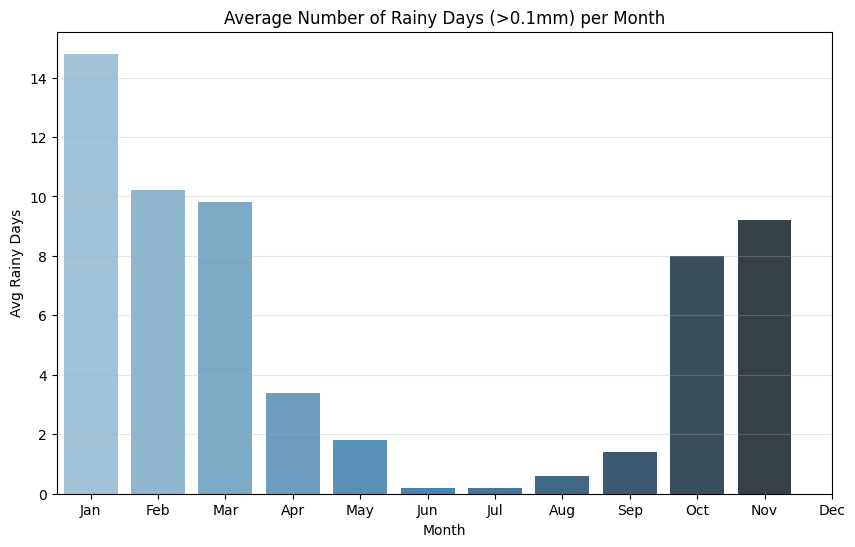

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Resample to Daily Totals (since your data is hourly)
# We only care if the WHOLE day had > 0.1mm
curr_df = datasets.get(target_lags[0])
daily_rain = curr_df['rain'].resample('D').sum()

rainy_days = daily_rain[daily_rain > 0.1]

# We normalize by the number of years to get "Average Rainy Days per Month"
unique_years = curr_df.index.year.nunique()
monthly_rain_counts = rainy_days.groupby(rainy_days.index.month).count() / unique_years

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_rain_counts.index, y=monthly_rain_counts.values, palette="Blues_d")

plt.title(f"Average Number of Rainy Days (>0.1mm) per Month")
plt.xlabel("Month")
plt.ylabel("Avg Rainy Days")
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', alpha=0.3)
plt.show()

**Checking feature correlations**

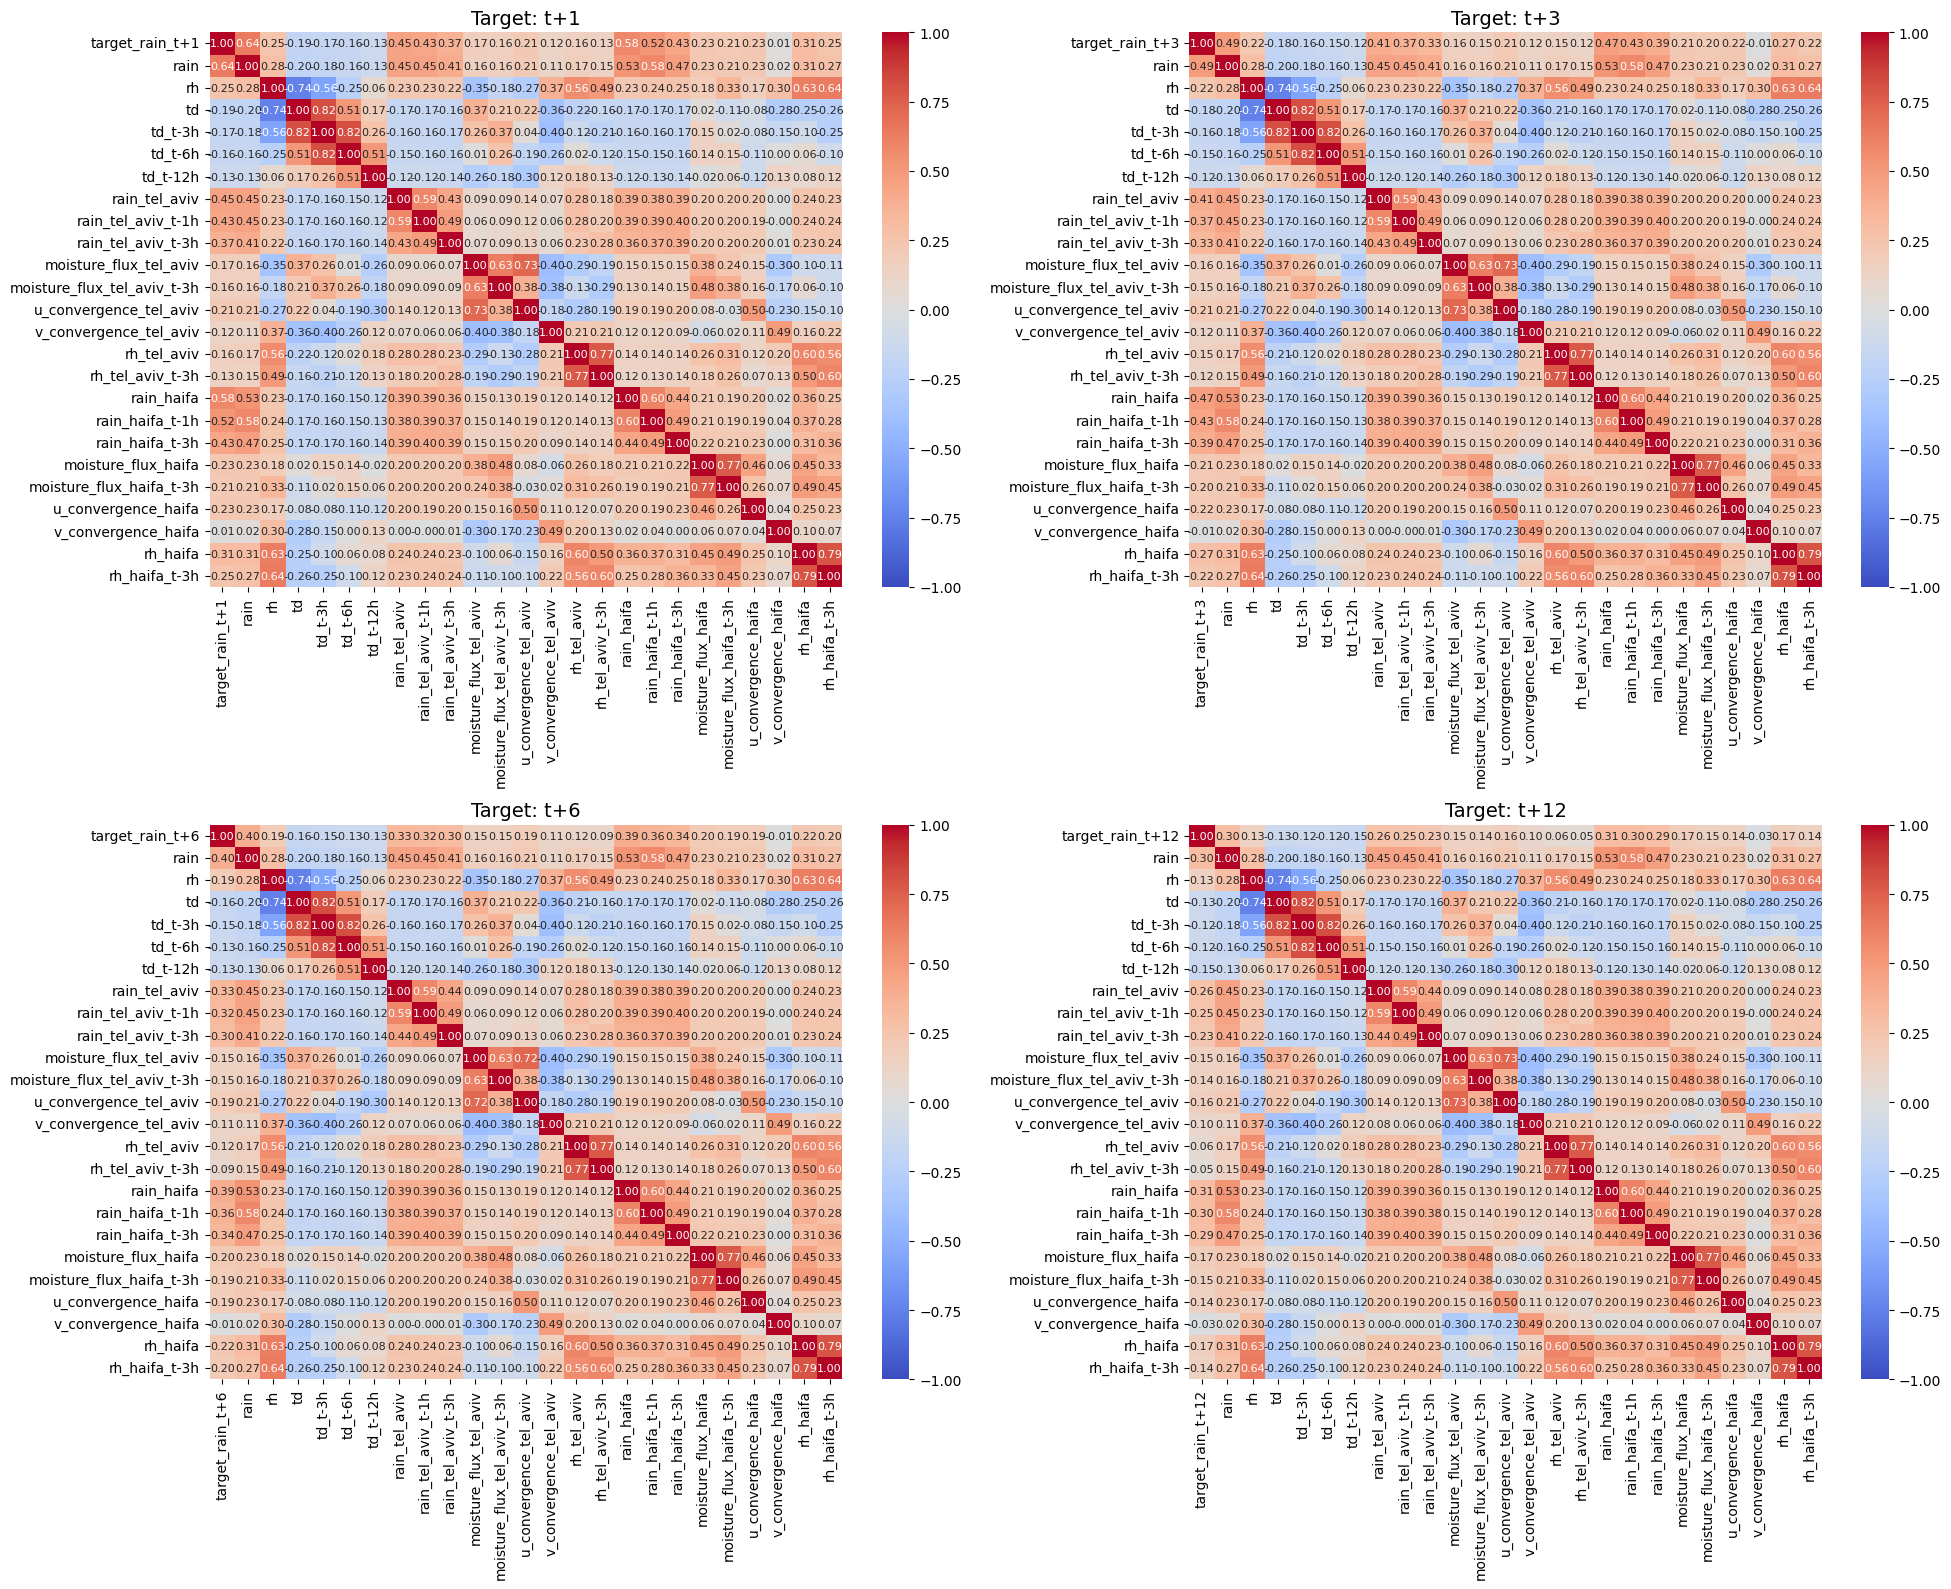

In [35]:
def plot_corr_heatmap(df: pd.DataFrame, target_lag: int, ax) -> None:
    winter_months = [10, 11, 12, 1, 2, 3]
    df_winter = df[df.index.month.isin(winter_months)]

    target_col = f'target_rain_t+{target_lag}'
    corr_cols = [target_col, 'rain', 'rh', 'td', 'td_t-3h', 'td_t-6h', 'td_t-12h',
                 'rain_tel_aviv', 'rain_tel_aviv_t-1h', 'rain_tel_aviv_t-3h',
                 'moisture_flux_tel_aviv', 'moisture_flux_tel_aviv_t-3h',
                 'u_convergence_tel_aviv', 'v_convergence_tel_aviv', 'rh_tel_aviv',
                 'rh_tel_aviv_t-3h', 'rain_haifa', 'rain_haifa_t-1h', 'rain_haifa_t-3h',
                 'moisture_flux_haifa', 'moisture_flux_haifa_t-3h', 'u_convergence_haifa',
                 'v_convergence_haifa', 'rh_haifa', 'rh_haifa_t-3h']

    plot_cols = [c for c in corr_cols if c in df_winter.columns]
    corr_matrix = df_winter[plot_cols].corr(method='spearman')

    # Pass the 'ax' argument to seaborn to constrain it to the grid cell
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Target: t+{target_lag}", fontsize=14)

# Create a 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))
axes = axes.flatten()

for i, lag in enumerate(target_lags):
    curr_df = datasets.get(lag)
    plot_corr_heatmap(curr_df, lag, axes[i])

plt.tight_layout()
plt.show()


In [ ]:
corr_series_dict = {}
winter_months = [10, 11, 12, 1, 2, 3]

# 1. Extract just the feature-to-target correlations for each horizon
for lag in target_lags:
    df_winter = datasets[lag][datasets[lag].index.month.isin(winter_months)]
    target_col = f'target_rain_t+{lag}'
    
    # Calculate spearman and grab JUST the column matching the target
    corr_matrix = df_winter.corr(method='spearman')
    target_corrs = corr_matrix[target_col].drop(target_col) # Drop self-correlation (1.0)
    
    corr_series_dict[f't+{lag}'] = target_corrs

df_shift = pd.DataFrame(corr_series_dict)

# 2. To measure predictive power, we care about the ABSOLUTE correlation 
last_lag = target_lags[-1]
df_shift['Abs_t+1'] = df_shift['t+1'].abs()
df_shift[f'Abs_t+{last_lag}'] = df_shift[f't+{last_lag}'].abs()

# Calculate the shift in absolute predictive power
shift_col_name = f'Power Shift (t+{last_lag} vs t+1)'
df_shift[shift_col_name] = df_shift[f'Abs_t+{last_lag}'] - df_shift['Abs_t+1']

# Drop the temporary absolute columns and sort by the shift
df_shift = df_shift.drop(columns=['Abs_t+1', f'Abs_t+{last_lag}'])
df_shift = df_shift.sort_values(by=shift_col_name, ascending=False)

# 3. Apply a beautiful background gradient (Green = Gained Power, Red = Lost Power)
df_styled = df_shift.style.background_gradient(cmap='RdYlGn', subset=[shift_col_name]) \
                          .background_gradient(cmap='coolwarm', subset=[f't+{lag}' for lag in target_lags]) \
                          .format("{:.3f}")

display(df_styled)


,t+1,t+3,t+6,t+12,Power Shift (t+12 vs t+1)
stdwd,-0.016,-0.045,-0.049,-0.053,0.036
v_convergence_haifa_t-1h,0.002,-0.008,-0.024,-0.027,0.025
td_t-12h,-0.128,-0.124,-0.126,-0.148,0.019
v_convergence_haifa_t-3h,-0.008,-0.013,-0.027,-0.026,0.018
v_convergence_haifa_t-2h,-0.008,-0.009,-0.025,-0.025,0.016
u_vec,-0.003,-0.010,-0.001,0.019,0.016
u_vec_t-12h,0.018,0.012,-0.008,-0.033,0.015
v_convergence_haifa,0.011,-0.009,-0.013,-0.026,0.015
v_vec,0.160,0.180,0.182,0.171,0.012
wdmax,-0.065,-0.092,-0.084,-0.076,0.011


## Explaining Winter Season Correlation Shifts

1. **The Nowcast Features Losing Correlation:**
    - rain (local): Dropped from 0.639 (t+1) to 0.304 (t+12)
    - rain_haifa: Dropped from 0.581 (t+1) to 0.307 (t+12)

    Current, immediate rainfall is the ultimate predictor for rain 1 hour from now (a storm cell is directly above us). However, storm cells move fast so rain at the current moment gives practically zero physical information about whether a different storm cell will arrive in 12 hours.

2. **The Synoptic Fuel Stays Stable:**
    - moisture_flux_haifa: 0.231 (t+1) down to 0.174 (t+12)
    - td (Dew Point): -0.188 (t+1) down to -0.130 (t+12)

    Moisture flux and regional dew point don't represent tiny fast-moving storm cells, they represent the macro-level weather system (synoptic scale). A giant humid low-pressure system lingering over the Mediterranean dictates the probability of rain for days at a time.

## XGBoost model for each timelagged dataset from t+1 to t+12

In [37]:
# Create dictionaries to store the outputs for each time lag
models = {}
predictions = {}
test_sets = {} # Extremely useful for running your metric functions later!

val_start_date = "2023-01-01"
test_start_date = "2024-01-01"
ignore_cols = ['timestamp', 'station_id', 'longitude', 'latitude']

for lag in target_lags:
    target_col_name = f'target_rain_t+{lag}'
    print(f"--- Training Model for t+{lag} ---")
    
    # Get the dataset and constraints for the current lag
    current_df = datasets[lag]
    current_constraints = constraints_dict[lag]
    
    # 1. Temporal Split
    X_train, X_val, X_test, y_train, y_val, y_test = temporal_split(
        current_df,
        target_col_name,
        val_start_date,
        test_start_date
    )
    
    # 2. Drop Ignore Columns
    X_train = X_train.drop(columns=ignore_cols, errors='ignore')
    X_val = X_val.drop(columns=ignore_cols, errors='ignore')
    X_test = X_test.drop(columns=ignore_cols, errors='ignore')
    
    # 3. Create Sample Weights dynamically based on the current y_train
    current_sample_weights = np.ones(len(y_train))
    current_sample_weights[y_train > 0] = 10.0
    
    # 4. Initialize Model with dynamic constraints
    current_model = xgb.XGBRegressor(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        objective='reg:tweedie',
        tweedie_variance_power=1.5,
        n_jobs=-1,
        early_stopping_rounds=50,
        missing=np.nan,
        monotone_constraints=current_constraints
    )
    
    # 5. Fit Model
    current_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        sample_weight=current_sample_weights,
        verbose=False
    )
    
    # 6. Predict on the test set
    preds_test = current_model.predict(X_test)
    
    # 7. Store everything back into our dictionaries
    models[lag] = current_model
    predictions[lag] = preds_test
    test_sets[lag] = {'X_test': X_test, 'y_test': y_test}
    
    print(f"Model for t+{lag} trained successfully!\n")


--- Training Model for t+1 ---
Model for t+1 trained successfully!

--- Training Model for t+3 ---
Model for t+3 trained successfully!

--- Training Model for t+6 ---
Model for t+6 trained successfully!

--- Training Model for t+12 ---
Model for t+12 trained successfully!



**BASELINE 0 Complexity Model**

In [38]:
preds_presistence = X_test['rain']

Conditional RMSE

In [39]:
def storm_rmse(y_pred, y_test, model_name):
    mask_rainy = y_test > 0.1

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(model_name + ':')
    print(f"GLOBAL t+1 RMSE: {rmse:.4f} mm")

    if mask_rainy.sum() > 0:
        y_rainy = y_test[mask_rainy]
        pred_rainy = y_pred[mask_rainy]
        rmse_rainy = np.sqrt(mean_squared_error(y_rainy, pred_rainy))
        print(f"Storm-Only t+1 RMSE: {rmse_rainy:.4f} mm")

        # Calculate Bias: Are we systematically under or over forecasting?
        # Negative = Under-forecasting (Dangerous)
        bias = np.mean(y_pred[mask_rainy] - y_test[mask_rainy])
        
        # Calculate Scatter Index: Relative error
        rmse_rainy = np.sqrt(mean_squared_error(y_test[mask_rainy], y_pred[mask_rainy]))
        scatter_index = (rmse_rainy / np.mean(y_test[mask_rainy])) * 100
        
        print(f"Storm Intensity Bias: {bias:.2f} mm")
        print(f"Storm Scatter Index: {scatter_index:.1f}%")
        print()
    else:
        print("No rain events in the test set!")


for lag in target_lags:
    y_test_current = test_sets[lag]['y_test']
    preds_current = predictions[lag]
    
    print(f"========== RESULTS FOR T+{lag} ==========")
    storm_rmse(preds_current, y_test_current, f'XGBoost t+{lag}')



========== RESULTS FOR T+1 ==========
XGBoost t+1:
GLOBAL t+1 RMSE: 0.4724 mm
Storm-Only t+1 RMSE: 2.1084 mm
Storm Intensity Bias: -0.64 mm
Storm Scatter Index: 124.9%

========== RESULTS FOR T+3 ==========
XGBoost t+3:
GLOBAL t+1 RMSE: 0.5064 mm
Storm-Only t+1 RMSE: 2.1995 mm
Storm Intensity Bias: -0.87 mm
Storm Scatter Index: 130.2%

========== RESULTS FOR T+6 ==========
XGBoost t+6:
GLOBAL t+1 RMSE: 0.5157 mm
Storm-Only t+1 RMSE: 2.2536 mm
Storm Intensity Bias: -0.99 mm
Storm Scatter Index: 133.5%

========== RESULTS FOR T+12 ==========
XGBoost t+12:
GLOBAL t+1 RMSE: 0.5438 mm
Storm-Only t+1 RMSE: 2.3076 mm
Storm Intensity Bias: -1.06 mm
Storm Scatter Index: 136.6%



## Plotting feature importances and impacts

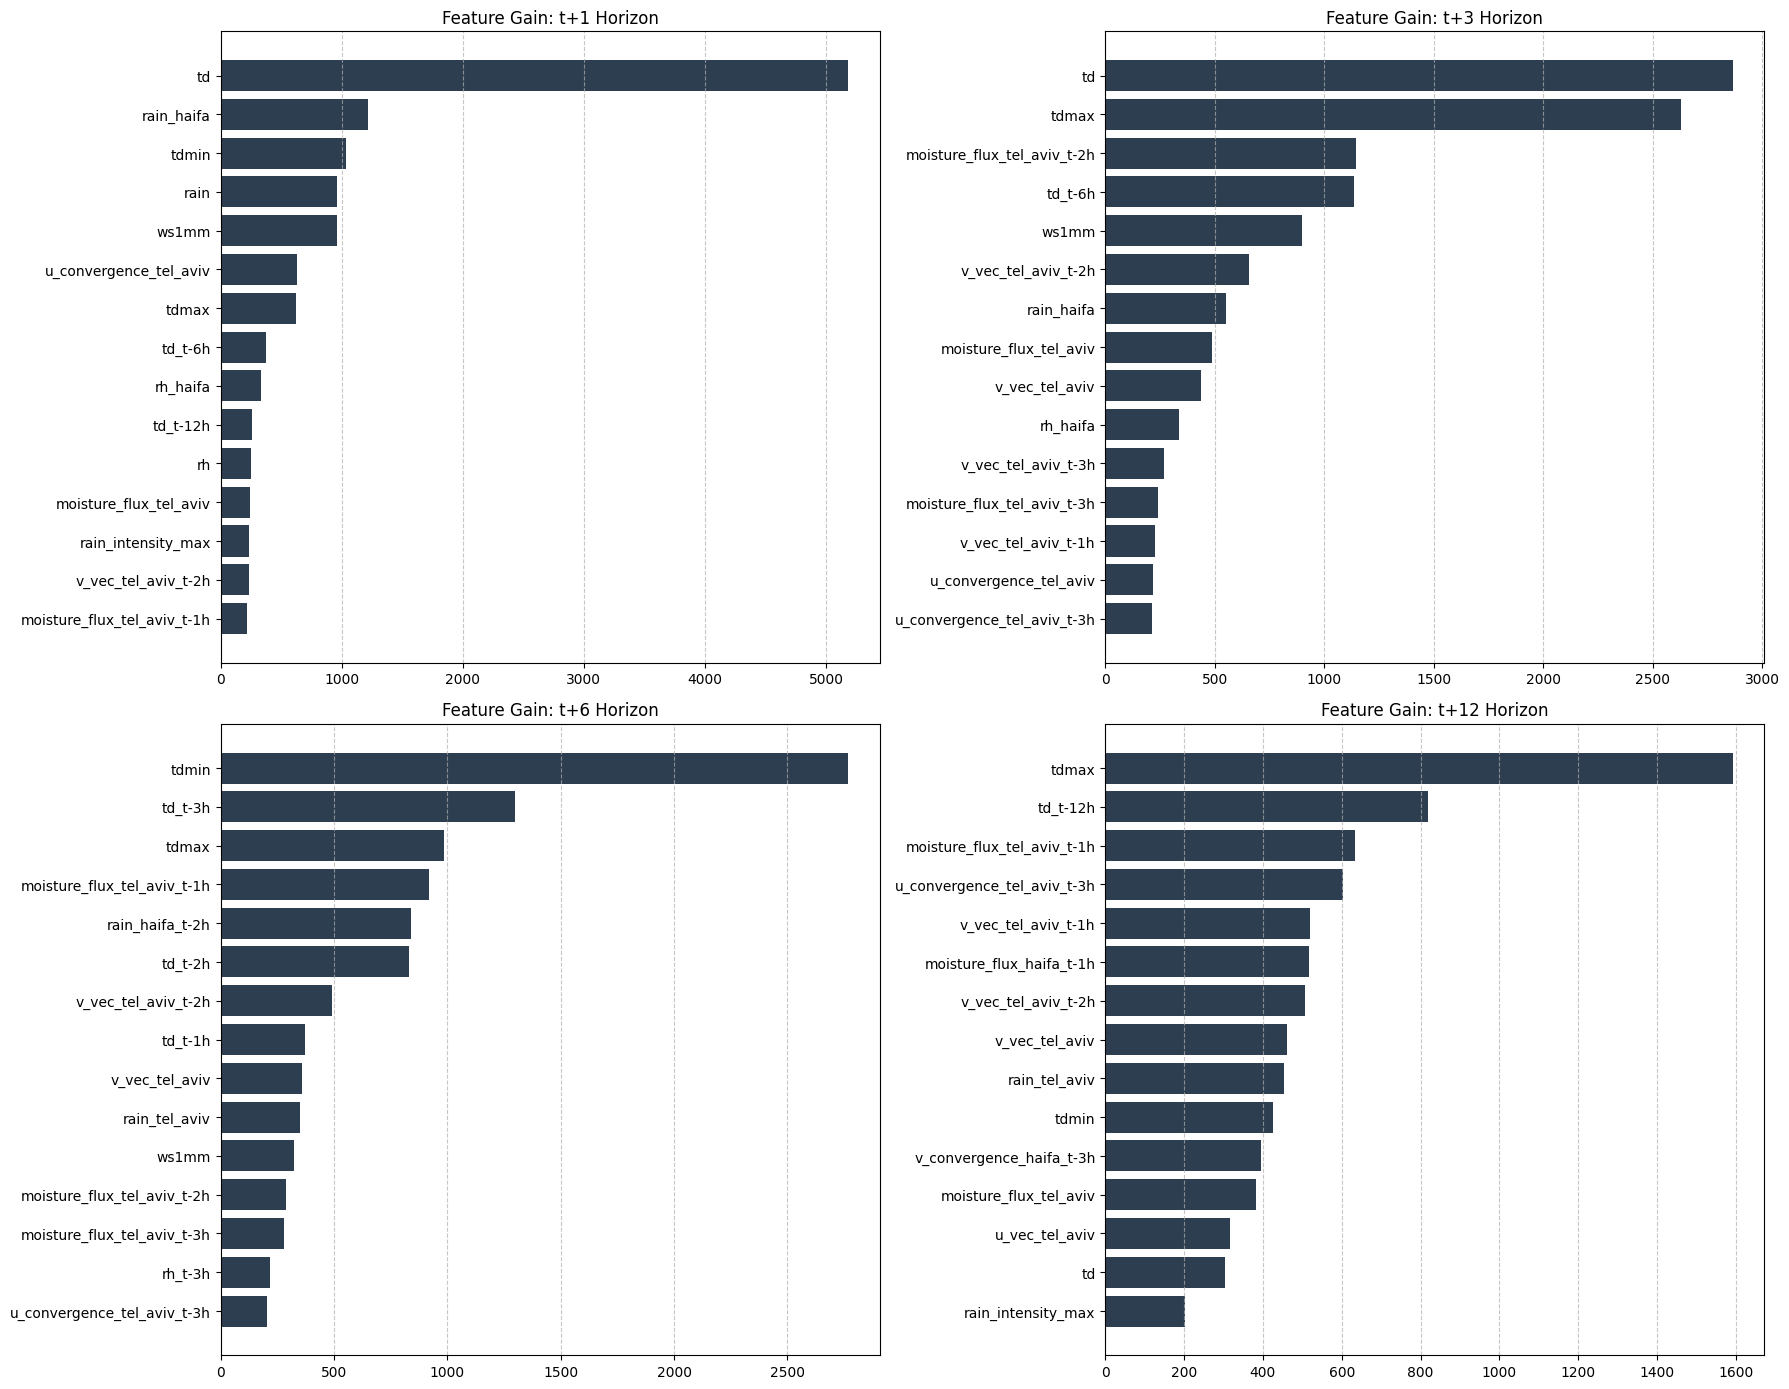

In [40]:
import matplotlib.pyplot as plt

# Create a 2x2 grid for your 4 target lags
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
axes = axes.flatten() # Flatten 2D array of axes for easy looping

for i, lag in enumerate(target_lags):
    model = models[lag]
    ax = axes[i]
    
    importance = model.get_booster().get_score(importance_type='gain')
    sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:15]
    features, scores = zip(*sorted_importance)
    
    ax.barh(features, scores, color='#2c3e50')
    ax.set_title(f'Feature Gain: t+{lag} Horizon')
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Feature Importance Shift Analysis

In [42]:
importance_dict = {}

# 1. Extract raw importance scores for each horizon
for lag in target_lags:
    model = models[lag]
    # get_score returns a dictionary of {feature_name: gain_value}
    raw_scores = model.get_booster().get_score(importance_type='gain')
    importance_dict[f't+{lag}'] = pd.Series(raw_scores)

df_importance = pd.DataFrame(importance_dict)

# If a feature wasn't used in a specific model, its NaN. Fill with 0% importance.
df_importance = df_importance.fillna(0.0)

# 2. Normalize each column to 100% so we can safely compare between models
for lag in target_lags:
    col = f't+{lag}'
    df_importance[col] = (df_importance[col] / df_importance[col].sum()) * 100

# 3. Calculate the Shift in Relative Percentage
last_lag = target_lags[-1]
shift_col_name = f'Importance Shift (t+{last_lag} vs t+1)'
df_importance[shift_col_name] = df_importance[f't+{last_lag}'] - df_importance['t+1']

# Sort to see what gained the most % of importance
df_importance = df_importance.sort_values(by=shift_col_name, ascending=False)

# 4. Apply the background gradient! (Green = Model relies on this MORE over time)
df_importance_styled = df_importance.style.background_gradient(cmap='RdYlGn', subset=[shift_col_name]) \
                                          .background_gradient(cmap='Blues', subset=[f't+{lag}' for lag in target_lags]) \
                                          .format("{:.2f}%")

display(df_importance_styled)


,t+1,t+3,t+6,t+12,Importance Shift (t+12 vs t+1)
tdmax,3.49%,13.47%,5.44%,9.52%,6.03%
td_t-12h,1.46%,0.84%,0.76%,4.90%,3.44%
moisture_flux_haifa_t-1h,0.06%,0.20%,0.77%,3.09%,3.03%
v_vec_tel_aviv_t-1h,0.23%,1.16%,0.59%,3.11%,2.89%
u_convergence_tel_aviv_t-3h,0.91%,1.09%,1.12%,3.61%,2.70%
moisture_flux_tel_aviv_t-1h,1.25%,0.64%,5.07%,3.79%,2.54%
v_convergence_haifa_t-3h,0.03%,0.16%,0.31%,2.35%,2.32%
rain_tel_aviv,0.51%,0.52%,1.93%,2.71%,2.19%
v_vec_tel_aviv,0.79%,2.25%,1.98%,2.76%,1.97%
v_vec_tel_aviv_t-2h,1.33%,3.37%,2.72%,3.02%,1.69%


### **Key Insights from the Power Feature Shift:**

- **The 'Spark' vs The 'Fuel Line':** Notice the extreme drop in the td (Dew point) feature. At $t+1$, immediate temperature drops ($td$) govern 29% of the model's logic, because sudden drops cause immediate condensation. However, by $t+12$, this immediate "spark" is mathematically useless. Instead, the model's attention shifts drastically upward to the "fuel lines"—upstream synoptic metrics like moisture_flux and u_convergence off the coast of Tel Aviv and Haifa!

- **Current Rain is Discarded:** The model organically learned to strip predictive weight from rain and rain_haifa for the $t+12$ forecast. It learned that a rain cell currently over the station will have passed long before the 12-hour horizon arrives.

- **The Diurnal Cycle is Validated:** Features like td_t-12h drastically gain predictive power at the $t+12$ horizon. The model naturally latches onto the 24-hour diurnal heating cycle as a physical baseline for long-range target forecasting.

Binary representation of model's accuracy for precipitation

In [43]:
from sklearn.metrics import precision_recall_fscore_support

summary_metrics = []

for lag in target_lags:
    y_test_current = test_sets[lag]['y_test']
    preds_current = predictions[lag]
    X_test_current = test_sets[lag]['X_test']
    
    y_test_bin = (y_test_current >= 0.1).astype(int)
    preds_bin = (preds_current >= 0.5).astype(int)
    
    # 1. Get Classification Metrics specifically for the "Rain" class (Class 1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_bin, preds_bin, average='binary', zero_division=0)
    
    # 2. Replicate your Missed Rain Logic
    mask_miss = (y_test_current >= 0.1) & (preds_current < 0.5)
    # Use loc to safely grab only the misses
    df_misses = X_test_current.loc[mask_miss].copy()
    
    if df_misses.empty:
        events_missed = 0
        max_miss = 0.0
        avg_miss = 0.0
    else:
        df_misses['Actual'] = y_test_current.loc[mask_miss]
        events_missed = len(df_misses)
        max_miss = df_misses['Actual'].max()
        avg_miss = df_misses['Actual'].mean()
        
    # Append row
    summary_metrics.append({
        'Horizon': f't+{lag}',
        'Rain Recall (Detection %)': recall,
        'Rain Precision (Accuracy %)': precision,
        'Rain F1-Score': f1,
        'Total Storms Missed': events_missed,
        'Max Rain Missed': max_miss,
        'Avg Rain Missed': avg_miss
    })

# 3. Output as a clean Pandas DataFrame table!
df_metrics = pd.DataFrame(summary_metrics).set_index('Horizon')

# Format the floats so they look perfect
display(df_metrics.style.format({
    'Rain Recall (Detection %)': '{:.2f}',
    'Rain Precision (Accuracy %)': '{:.2f}',
    'Rain F1-Score': '{:.2f}',
    'Max Rain Missed': '{:.2f} mm/hr',
    'Avg Rain Missed': '{:.2f} mm/hr'
}).background_gradient(cmap='YlOrRd', subset=['Total Storms Missed']))


,Rain Recall (Detection %),Rain Precision (Accuracy %),Rain F1-Score,Total Storms Missed,Max Rain Missed,Avg Rain Missed
Horizon,,,,,,
t+1,0.72,0.61,0.66,128,11.40 mm/hr,0.85 mm/hr
t+3,0.69,0.42,0.52,144,7.40 mm/hr,0.90 mm/hr
t+6,0.66,0.39,0.49,158,5.50 mm/hr,0.98 mm/hr
t+12,0.57,0.32,0.41,200,11.40 mm/hr,1.09 mm/hr


The metrics show a model that is primed to not miss storms as much as possible since the precision is always lower than the recal, this is especially evident in t+12 since the recall remains high 57% and the precision drops to 32%.

The gradual degradation in F1-Score proves the model is working perfectly and the training setup is perfect since in atmospheric science, chaos theory dictates that weather becomes exponentially harder to predict the further out you go.